# Phần 2 — EDA Cấp 2: DIAGNOSTIC
## "Why did it happen?"

Giả thuyết nhân quả, so sánh phân khúc, xác định bất thường có bằng chứng hỗ trợ.

---
**Câu hỏi chẩn đoán:**
- Tại sao doanh thu peak vào các tháng cuối năm?
- Promotions ảnh hưởng thế nào đến conversion?
- Tại sao một số phân khúc có return rate cao hơn?
- Bất thường nào trong dữ liệu cần chú ý?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_all
from src.utils import load_config, set_seed, save_fig

set_seed(42)
cfg = load_config('../config.yaml')
cfg['paths']['dataset']         = '../dataset'
cfg['paths']['figures']         = '../outputs/figures'
cfg['paths']['report_figures']  = '../report/figures'

tables = load_all(cfg)
sales, orders, order_items = tables['sales'], tables['orders'], tables['order_items']
products, customers, geography = tables['products'], tables['customers'], tables['geography']
payments, returns, reviews = tables['payments'], tables['returns'], tables['reviews']
promotions, web_traffic, inventory = tables['promotions'], tables['web_traffic'], tables['inventory']

plt.rcParams.update({'figure.dpi':130,'figure.facecolor':'white',
    'axes.facecolor':'#f8f9fa','axes.grid':True,'grid.alpha':0.4,
    'font.size':11,'axes.titlesize':13})
COLORS = cfg['colors']
C1,C2,C3,C4,C5 = COLORS['primary'],COLORS['secondary'],COLORS['accent'],COLORS['neutral'],COLORS['highlight']

# Prep
oi_full = order_items.copy()
oi_full['line_rev'] = oi_full['quantity'] * oi_full['unit_price'] - oi_full['discount_amount'].fillna(0)
oi_full = oi_full.merge(orders[['order_id','order_date','order_status']], on='order_id', how='left')
oi_full = oi_full.merge(products[['product_id','category','segment','size']], on='product_id', how='left')
print('Setup xong.')

[10:08:30] INFO data_loader: Loading all datasets...
[10:08:31] INFO data_loader:   sales: 3,833 rows x 3 cols
[10:08:31] INFO data_loader:   submission: 548 rows x 3 cols
[10:08:31] INFO data_loader:   products: 2,412 rows x 8 cols
[10:08:31] INFO data_loader:   customers: 121,930 rows x 7 cols
[10:08:31] INFO data_loader:   geography: 39,948 rows x 4 cols
[10:08:31] INFO data_loader:   promotions: 50 rows x 10 cols
[10:08:31] INFO data_loader:   orders: 646,945 rows x 8 cols
[10:08:31] INFO data_loader:   order_items: 714,669 rows x 7 cols
[10:08:31] INFO data_loader:   payments: 646,945 rows x 4 cols
[10:08:31] INFO data_loader:   shipments: 566,067 rows x 4 cols
[10:08:31] INFO data_loader:   returns: 39,939 rows x 7 cols
[10:08:31] INFO data_loader:   reviews: 113,551 rows x 7 cols
[10:08:31] INFO data_loader:   inventory: 60,247 rows x 17 cols
[10:08:31] INFO data_loader:   web_traffic: 3,652 rows x 7 cols


Setup xong.


## G1. Tác động của Khuyến mãi lên Doanh thu và Số đơn hàng
### Giả thuyết: Ngày có promo → doanh thu cao hơn ngày không có promo

In [2]:
# Build daily promo indicator
sales_diag = sales.copy()
sales_diag['GrossProfit'] = sales_diag['Revenue'] - sales_diag['COGS']

def has_promo(date):
    active = promotions[
        (promotions['start_date'] <= date) & (promotions['end_date'] >= date)
    ]
    return len(active) > 0

sales_diag['has_promo']    = sales_diag['Date'].apply(has_promo)
sales_diag['n_promos']     = sales_diag['Date'].apply(
    lambda d: len(promotions[(promotions['start_date']<=d)&(promotions['end_date']>=d)])
)

# So sánh ngày có/không có promo
promo_compare = sales_diag.groupby('has_promo').agg(
    n_days=('Revenue','count'),
    mean_revenue=('Revenue','mean'),
    median_revenue=('Revenue','median'),
    mean_gp=('GrossProfit','mean'),
).round(0)
print('Revenue trung bình: Ngày có promo vs không có promo:')
print(promo_compare)

# T-test
group_promo    = sales_diag[sales_diag['has_promo']]['Revenue']
group_nopromo  = sales_diag[~sales_diag['has_promo']]['Revenue']
t_stat, p_val  = stats.ttest_ind(group_promo, group_nopromo)
uplift_pct     = (group_promo.mean() / group_nopromo.mean() - 1) * 100
print(f'\nUplift revenue khi có promo: +{uplift_pct:.1f}%')
print(f'T-test: t={t_stat:.2f}, p={p_val:.4f} ({"Có ý nghĩa thống kê" if p_val<0.05 else "Không có ý nghĩa"})')

Revenue trung bình: Ngày có promo vs không có promo:
           n_days  mean_revenue  median_revenue   mean_gp
has_promo                                                
False        2126     4524083.0       3819856.0  901897.0
True         1707     3990789.0       3428607.0  204799.0

Uplift revenue khi có promo: +-11.8%
T-test: t=-6.28, p=0.0000 (Có ý nghĩa thống kê)


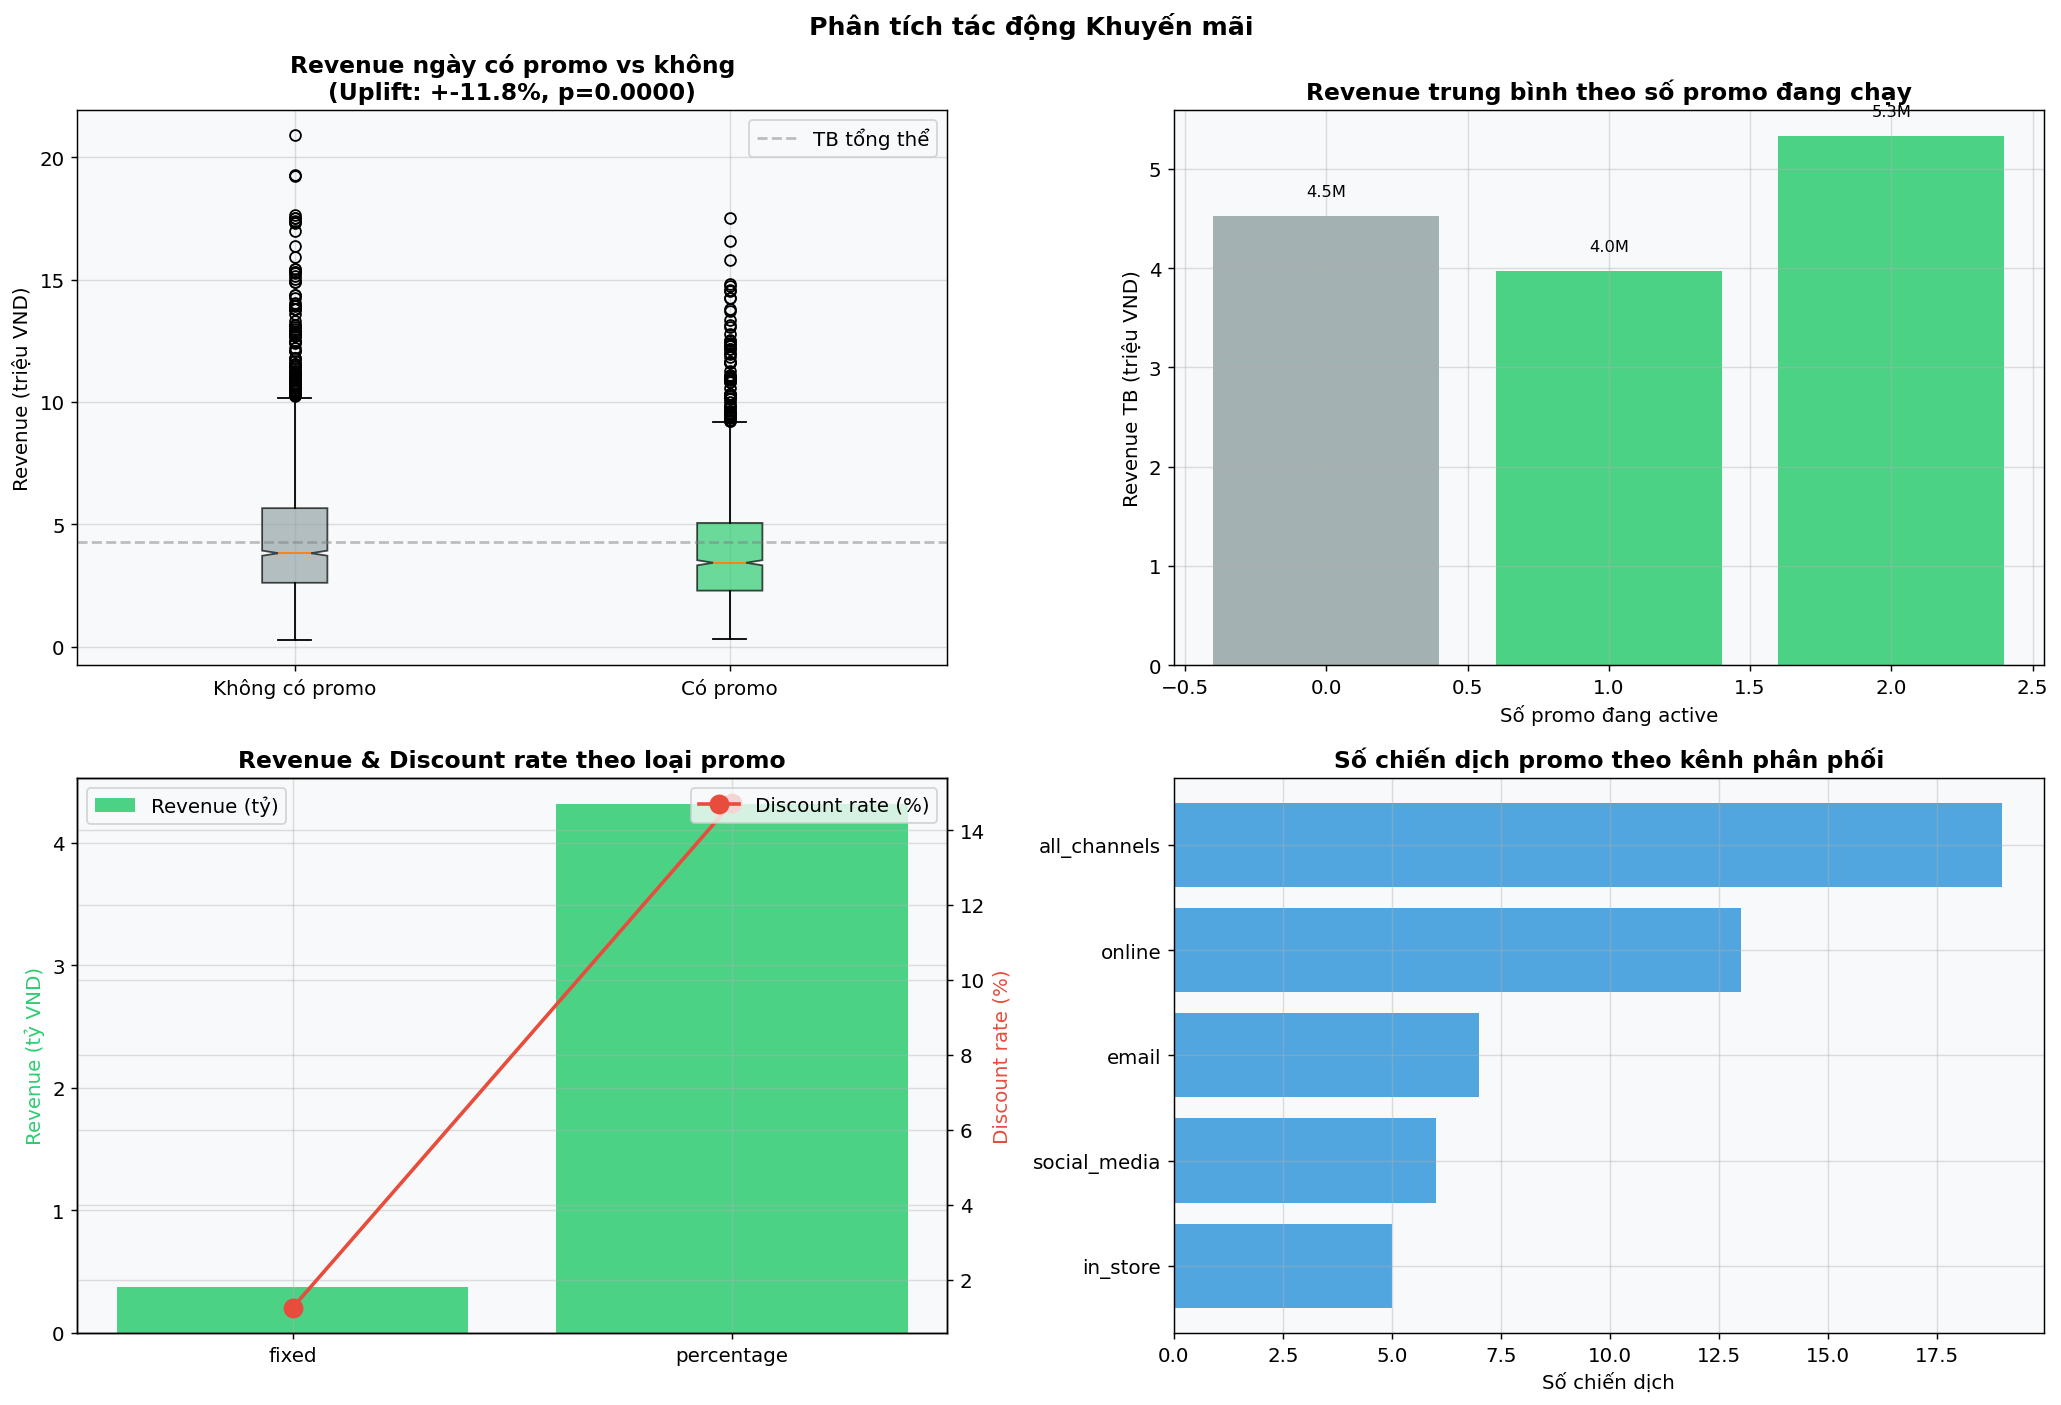

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Boxplot so sánh
data_box = [group_nopromo.values/1e6, group_promo.values/1e6]
bp = axes[0,0].boxplot(data_box, labels=['Không có promo', 'Có promo'],
                        patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], [C4, C1]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,0].set_title(f'Revenue ngày có promo vs không\n(Uplift: +{uplift_pct:.1f}%, p={p_val:.4f})',
                     fontweight='bold')
axes[0,0].set_ylabel('Revenue (triệu VND)')
axes[0,0].axhline(sales_diag['Revenue'].mean()/1e6, color='gray',
                   linestyle='--', alpha=0.5, label='TB tổng thể')
axes[0,0].legend()

# Revenue theo số promo cùng lúc
promo_n = sales_diag.groupby('n_promos')['Revenue'].mean().reset_index()
axes[0,1].bar(promo_n['n_promos'], promo_n['Revenue']/1e6,
               color=[C4 if n==0 else C1 for n in promo_n['n_promos']], alpha=0.85)
axes[0,1].set_title('Revenue trung bình theo số promo đang chạy', fontweight='bold')
axes[0,1].set_xlabel('Số promo đang active')
axes[0,1].set_ylabel('Revenue TB (triệu VND)')
for i, row in promo_n.iterrows():
    axes[0,1].text(row['n_promos'], row['Revenue']/1e6 + 0.2,
                    f"{row['Revenue']/1e6:.1f}M", ha='center', fontsize=9)

# ROI promo theo type
# Tính tổng discount từ order_items
oi_promo = order_items.merge(orders[['order_id','order_date']], on='order_id', how='left')
oi_promo = oi_promo.dropna(subset=['promo_id'])
oi_promo = oi_promo.merge(promotions[['promo_id','promo_type']], on='promo_id', how='left')
oi_promo['line_rev'] = oi_promo['quantity']*oi_promo['unit_price'] - oi_promo['discount_amount'].fillna(0)

promo_type_stats = oi_promo.groupby('promo_type').agg(
    total_discount=('discount_amount','sum'),
    total_revenue=('line_rev','sum'),
    n_lines=('order_id','count'),
).reset_index()
promo_type_stats['discount_rate'] = promo_type_stats['total_discount'] / (
    promo_type_stats['total_revenue'] + promo_type_stats['total_discount'])

axes[1,0].bar(promo_type_stats['promo_type'],
               promo_type_stats['total_revenue']/1e9, color=C1, alpha=0.85, label='Revenue (tỷ)')
ax_twin = axes[1,0].twinx()
ax_twin.plot(promo_type_stats['promo_type'],
              promo_type_stats['discount_rate']*100, 'o-', color=C3, linewidth=2,
              markersize=10, label='Discount rate (%)')
axes[1,0].set_title('Revenue & Discount rate theo loại promo', fontweight='bold')
axes[1,0].set_ylabel('Revenue (tỷ VND)', color=C1)
ax_twin.set_ylabel('Discount rate (%)', color=C3)
axes[1,0].legend(loc='upper left')
ax_twin.legend(loc='upper right')

# Promo theo kênh
promo_ch = promotions.groupby('promo_channel').size().dropna().sort_values(ascending=True)
if len(promo_ch) > 0:
    axes[1,1].barh(promo_ch.index.astype(str), promo_ch.values, color=C2, alpha=0.85)
    axes[1,1].set_title('Số chiến dịch promo theo kênh phân phối', fontweight='bold')
    axes[1,1].set_xlabel('Số chiến dịch')
else:
    axes[1,1].text(0.5, 0.5, 'Không có dữ liệu promo_channel',
                   ha='center', va='center', transform=axes[1,1].transAxes)

plt.suptitle('Phân tích tác động Khuyến mãi', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'G1_promo_impact', cfg)
plt.show()

## G2. Return rate theo Segment, Size, Category — Tìm điểm yếu sản phẩm

In [4]:
# Tính return rate theo segment/size/category
def return_rate_by(col):
    oi_col = oi_full.groupby(col)['order_id'].count().rename('n_ordered')
    ret_col = returns.merge(products[['product_id', col]], on='product_id', how='left')
    ret_col = ret_col.groupby(col)['return_id'].count().rename('n_returned')
    df = pd.concat([oi_col, ret_col], axis=1).fillna(0)
    df['return_rate'] = df['n_returned'] / df['n_ordered'] * 100
    return df.sort_values('return_rate', ascending=False)

rr_seg  = return_rate_by('segment')
rr_cat  = return_rate_by('category')
rr_size = return_rate_by('size')

print('Return rate theo segment:')
print(rr_seg[['n_ordered','n_returned','return_rate']])
print('\nReturn rate theo category:')
print(rr_cat[['n_ordered','n_returned','return_rate']])
print('\nReturn rate theo size:')
print(rr_size[['n_ordered','n_returned','return_rate']])

Return rate theo segment:
             n_ordered  n_returned  return_rate
segment                                        
Trendy           37159        2126     5.721360
Activewear      230375       13085     5.679870
Performance      96730        5442     5.625969
Everyday        182533       10143     5.556803
Premium          31032        1722     5.549111
Standard         10937         601     5.495108
Balanced        103333        5613     5.431953
All-weather      22570        1207     5.347807

Return rate theo category:
            n_ordered  n_returned  return_rate
category                                      
GenZ            37159        2126     5.721360
Outdoor        259986       14720     5.661843
Streetwear     393533       21799     5.539307
Casual          23991        1294     5.393689

Return rate theo size:
      n_ordered  n_returned  return_rate
size                                    
S        172042        9723     5.651527
L        173174        9741     5.624

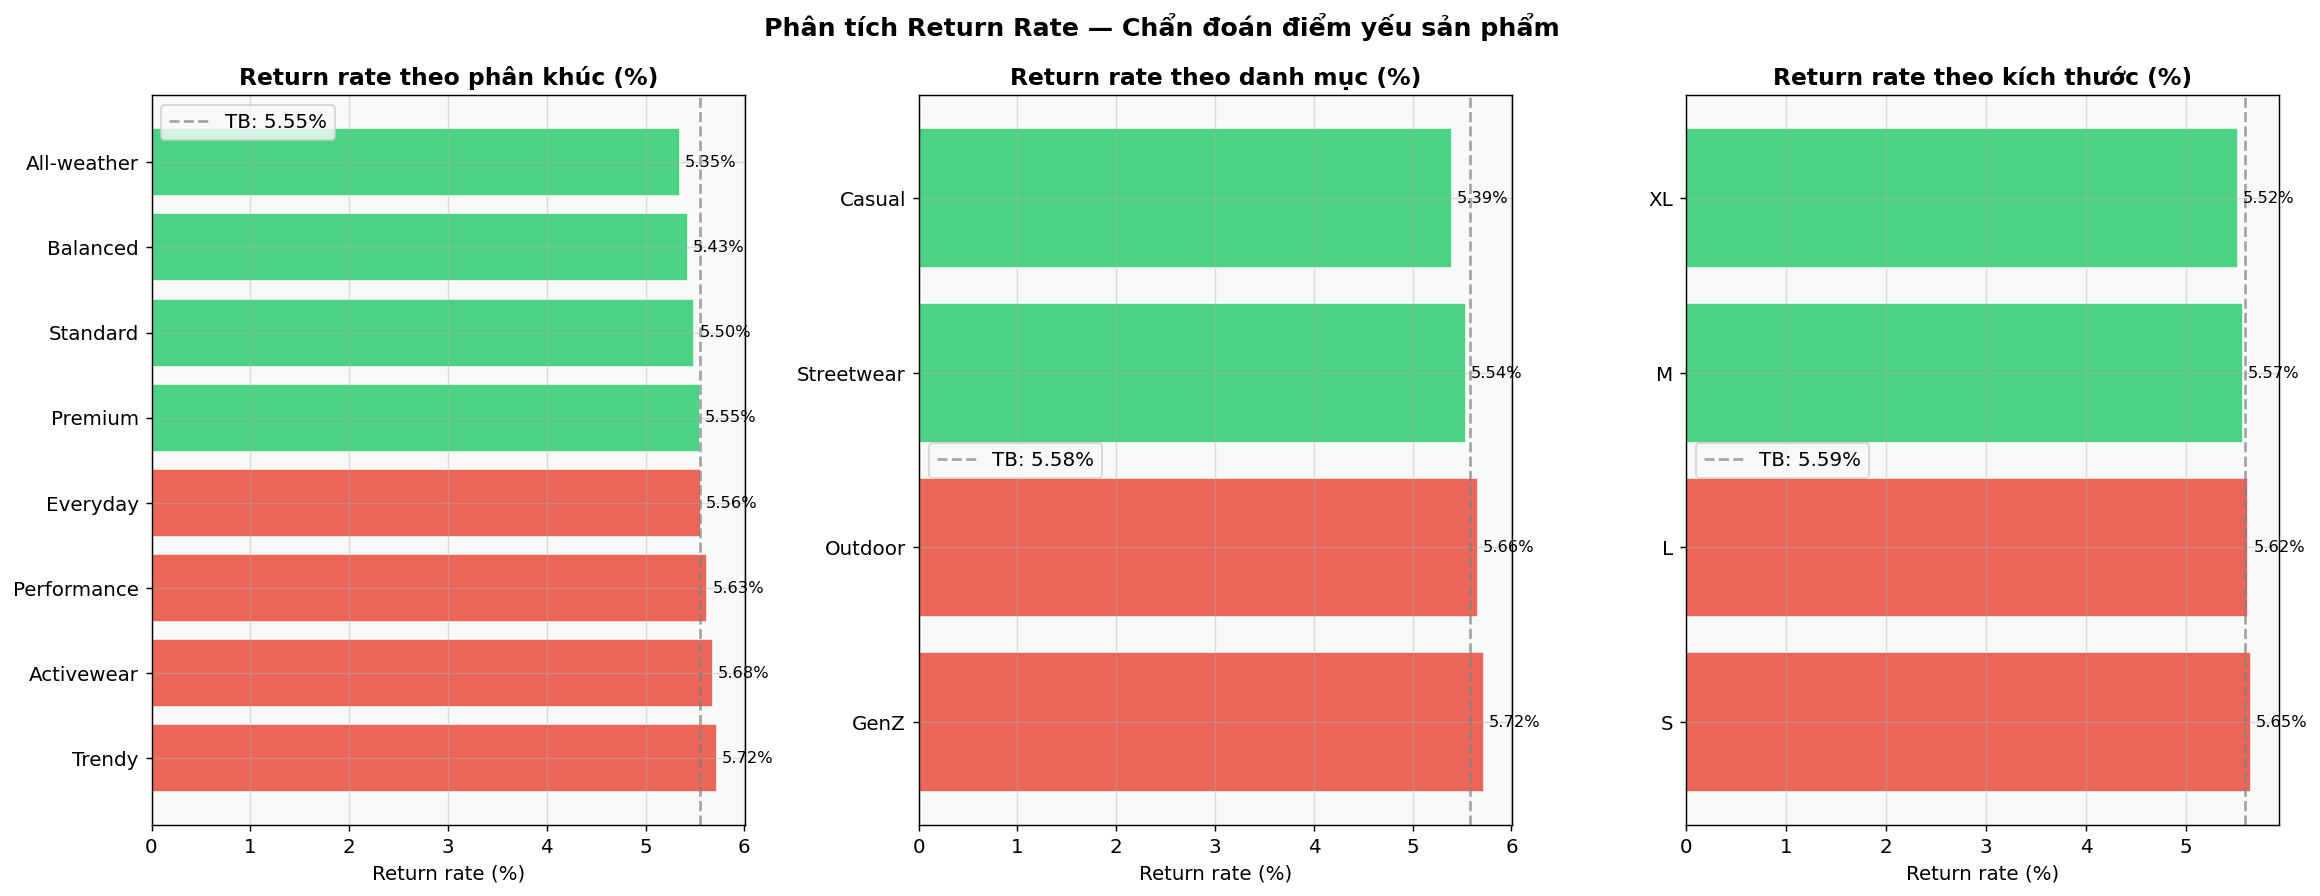

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, df, title, col in zip(
    axes,
    [rr_seg, rr_cat, rr_size],
    ['Return rate theo phân khúc (%)', 'Return rate theo danh mục (%)', 'Return rate theo kích thước (%)'],
    ['segment', 'category', 'size']
):
    bar_colors = [C3 if v > df['return_rate'].mean() else C1 for v in df['return_rate']]
    bars = ax.barh(df.index, df['return_rate'], color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axvline(df['return_rate'].mean(), color='gray', linestyle='--', alpha=0.7,
                label=f"TB: {df['return_rate'].mean():.2f}%")
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Return rate (%)')
    ax.legend()
    for bar in bars:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.2f}%', va='center', fontsize=9)

plt.suptitle('Phân tích Return Rate — Chẩn đoán điểm yếu sản phẩm', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'G2_return_rate_analysis', cfg)
plt.show()

## G3. Web Traffic → Conversion Analysis (Lead Indicator)
### Giả thuyết: Traffic hôm nay → Đơn hàng ngày mai/tuần sau

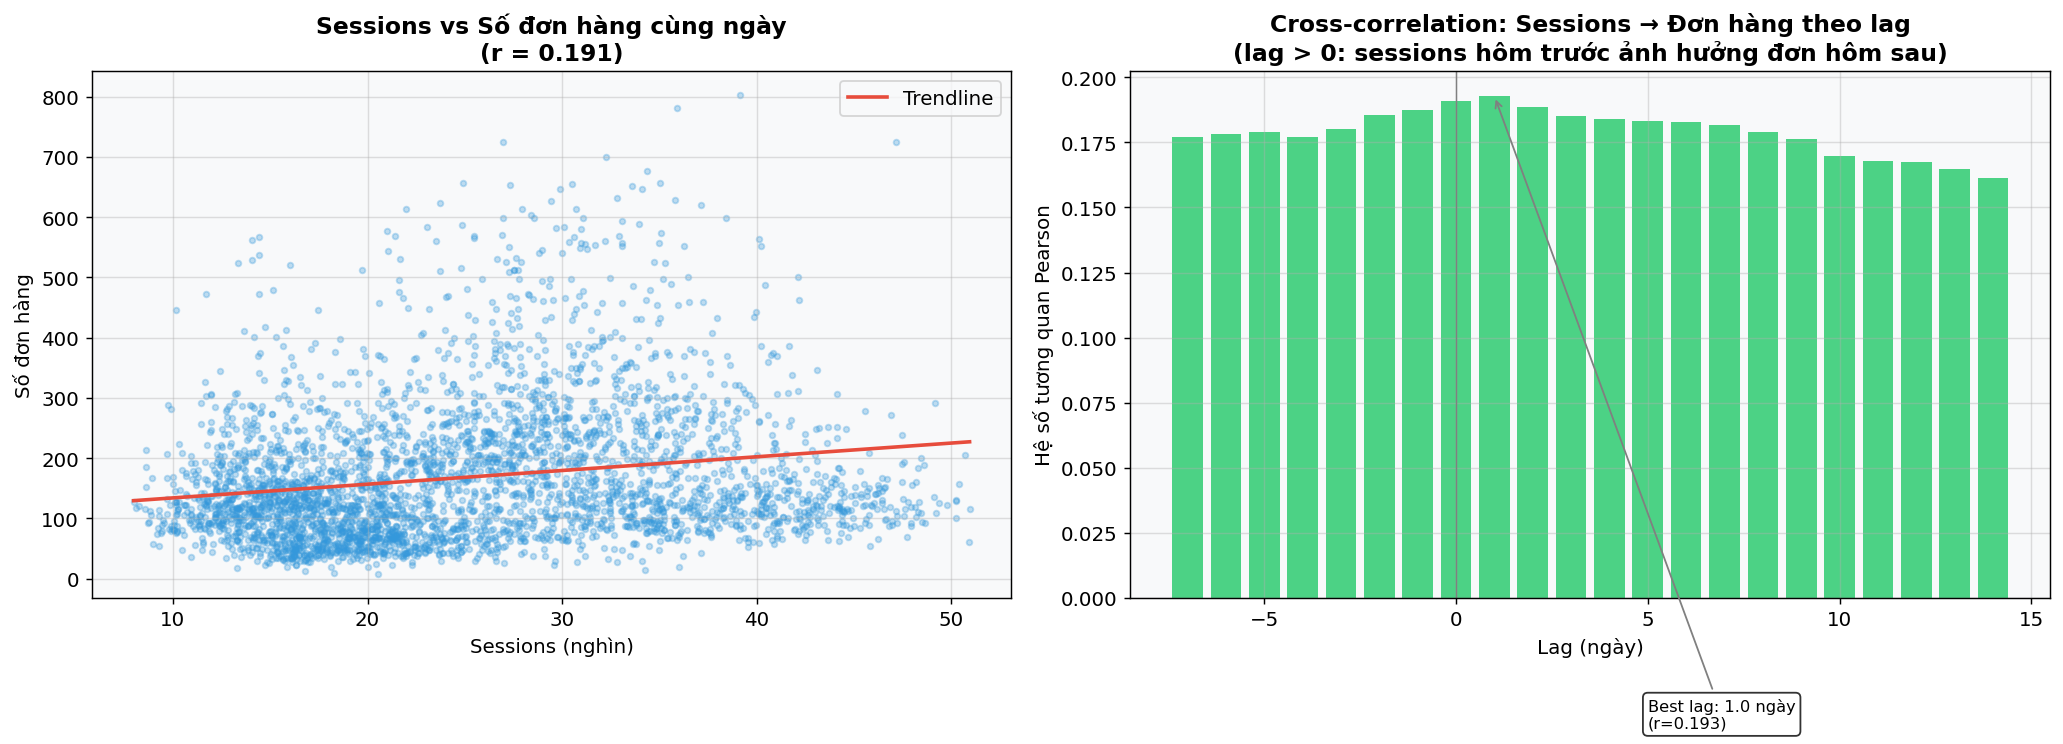

Tương quan tốt nhất tại lag = 1 ngày (r = 0.193)
→ Web sessions là leading indicator của đơn hàng!


In [6]:
# Daily orders count
daily_orders_count = orders.groupby('order_date').agg(
    n_orders=('order_id','count')
).reset_index().rename(columns={'order_date':'date'})
daily_orders_count['date'] = pd.to_datetime(daily_orders_count['date'])

# Merge với web traffic tổng theo ngày
wt_daily = web_traffic.groupby('date').agg(sessions=('sessions','sum')).reset_index()
wt_daily['date'] = pd.to_datetime(wt_daily['date'])

merged = wt_daily.merge(daily_orders_count, on='date', how='inner')

# Cross-correlation: lag 0 đến lag 14
max_lag = 14
correlations = []
for lag in range(-7, max_lag+1):
    shifted_sessions = merged['sessions'].shift(lag)  # lag>0: sessions trước orders
    corr = merged['n_orders'].corr(shifted_sessions)
    correlations.append({'lag': lag, 'correlation': corr})
corr_df = pd.DataFrame(correlations)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(merged['sessions']/1e3, merged['n_orders'], alpha=0.3, color=C2, s=10)
z = np.polyfit(merged['sessions'].dropna(), merged['n_orders'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(merged['sessions'].min(), merged['sessions'].max(), 100)
axes[0].plot(x_line/1e3, p(x_line), color=C3, linewidth=2, label=f'Trendline')
corr_0 = merged['sessions'].corr(merged['n_orders'])
axes[0].set_title(f'Sessions vs Số đơn hàng cùng ngày\n(r = {corr_0:.3f})', fontweight='bold')
axes[0].set_xlabel('Sessions (nghìn)')
axes[0].set_ylabel('Số đơn hàng')
axes[0].legend()

# Cross-correlation plot
colors_corr = [C1 if v > 0 else C3 for v in corr_df['correlation']]
axes[1].bar(corr_df['lag'], corr_df['correlation'], color=colors_corr, alpha=0.85)
axes[1].axvline(0, color='gray', linestyle='-', linewidth=0.8)
axes[1].axhline(0, color='gray', linewidth=0.5)
best_lag = corr_df.loc[corr_df['correlation'].abs().idxmax()]
axes[1].annotate(f"Best lag: {best_lag['lag']} ngày\n(r={best_lag['correlation']:.3f})",
                  xy=(best_lag['lag'], best_lag['correlation']),
                  xytext=(5, -0.05), fontsize=9,
                  arrowprops=dict(arrowstyle='->', color='gray'),
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
axes[1].set_title('Cross-correlation: Sessions → Đơn hàng theo lag\n(lag > 0: sessions hôm trước ảnh hưởng đơn hôm sau)',
                   fontweight='bold')
axes[1].set_xlabel('Lag (ngày)')
axes[1].set_ylabel('Hệ số tương quan Pearson')

plt.tight_layout()
save_fig(fig, 'G3_traffic_conversion', cfg)
plt.show()

print(f"Tương quan tốt nhất tại lag = {int(best_lag['lag'])} ngày (r = {best_lag['correlation']:.3f})")
print("→ Web sessions là leading indicator của đơn hàng!")

## G4. Anomaly Detection trong Doanh thu
### STL Residual ±2σ — Phát hiện ngày bất thường có bằng chứng

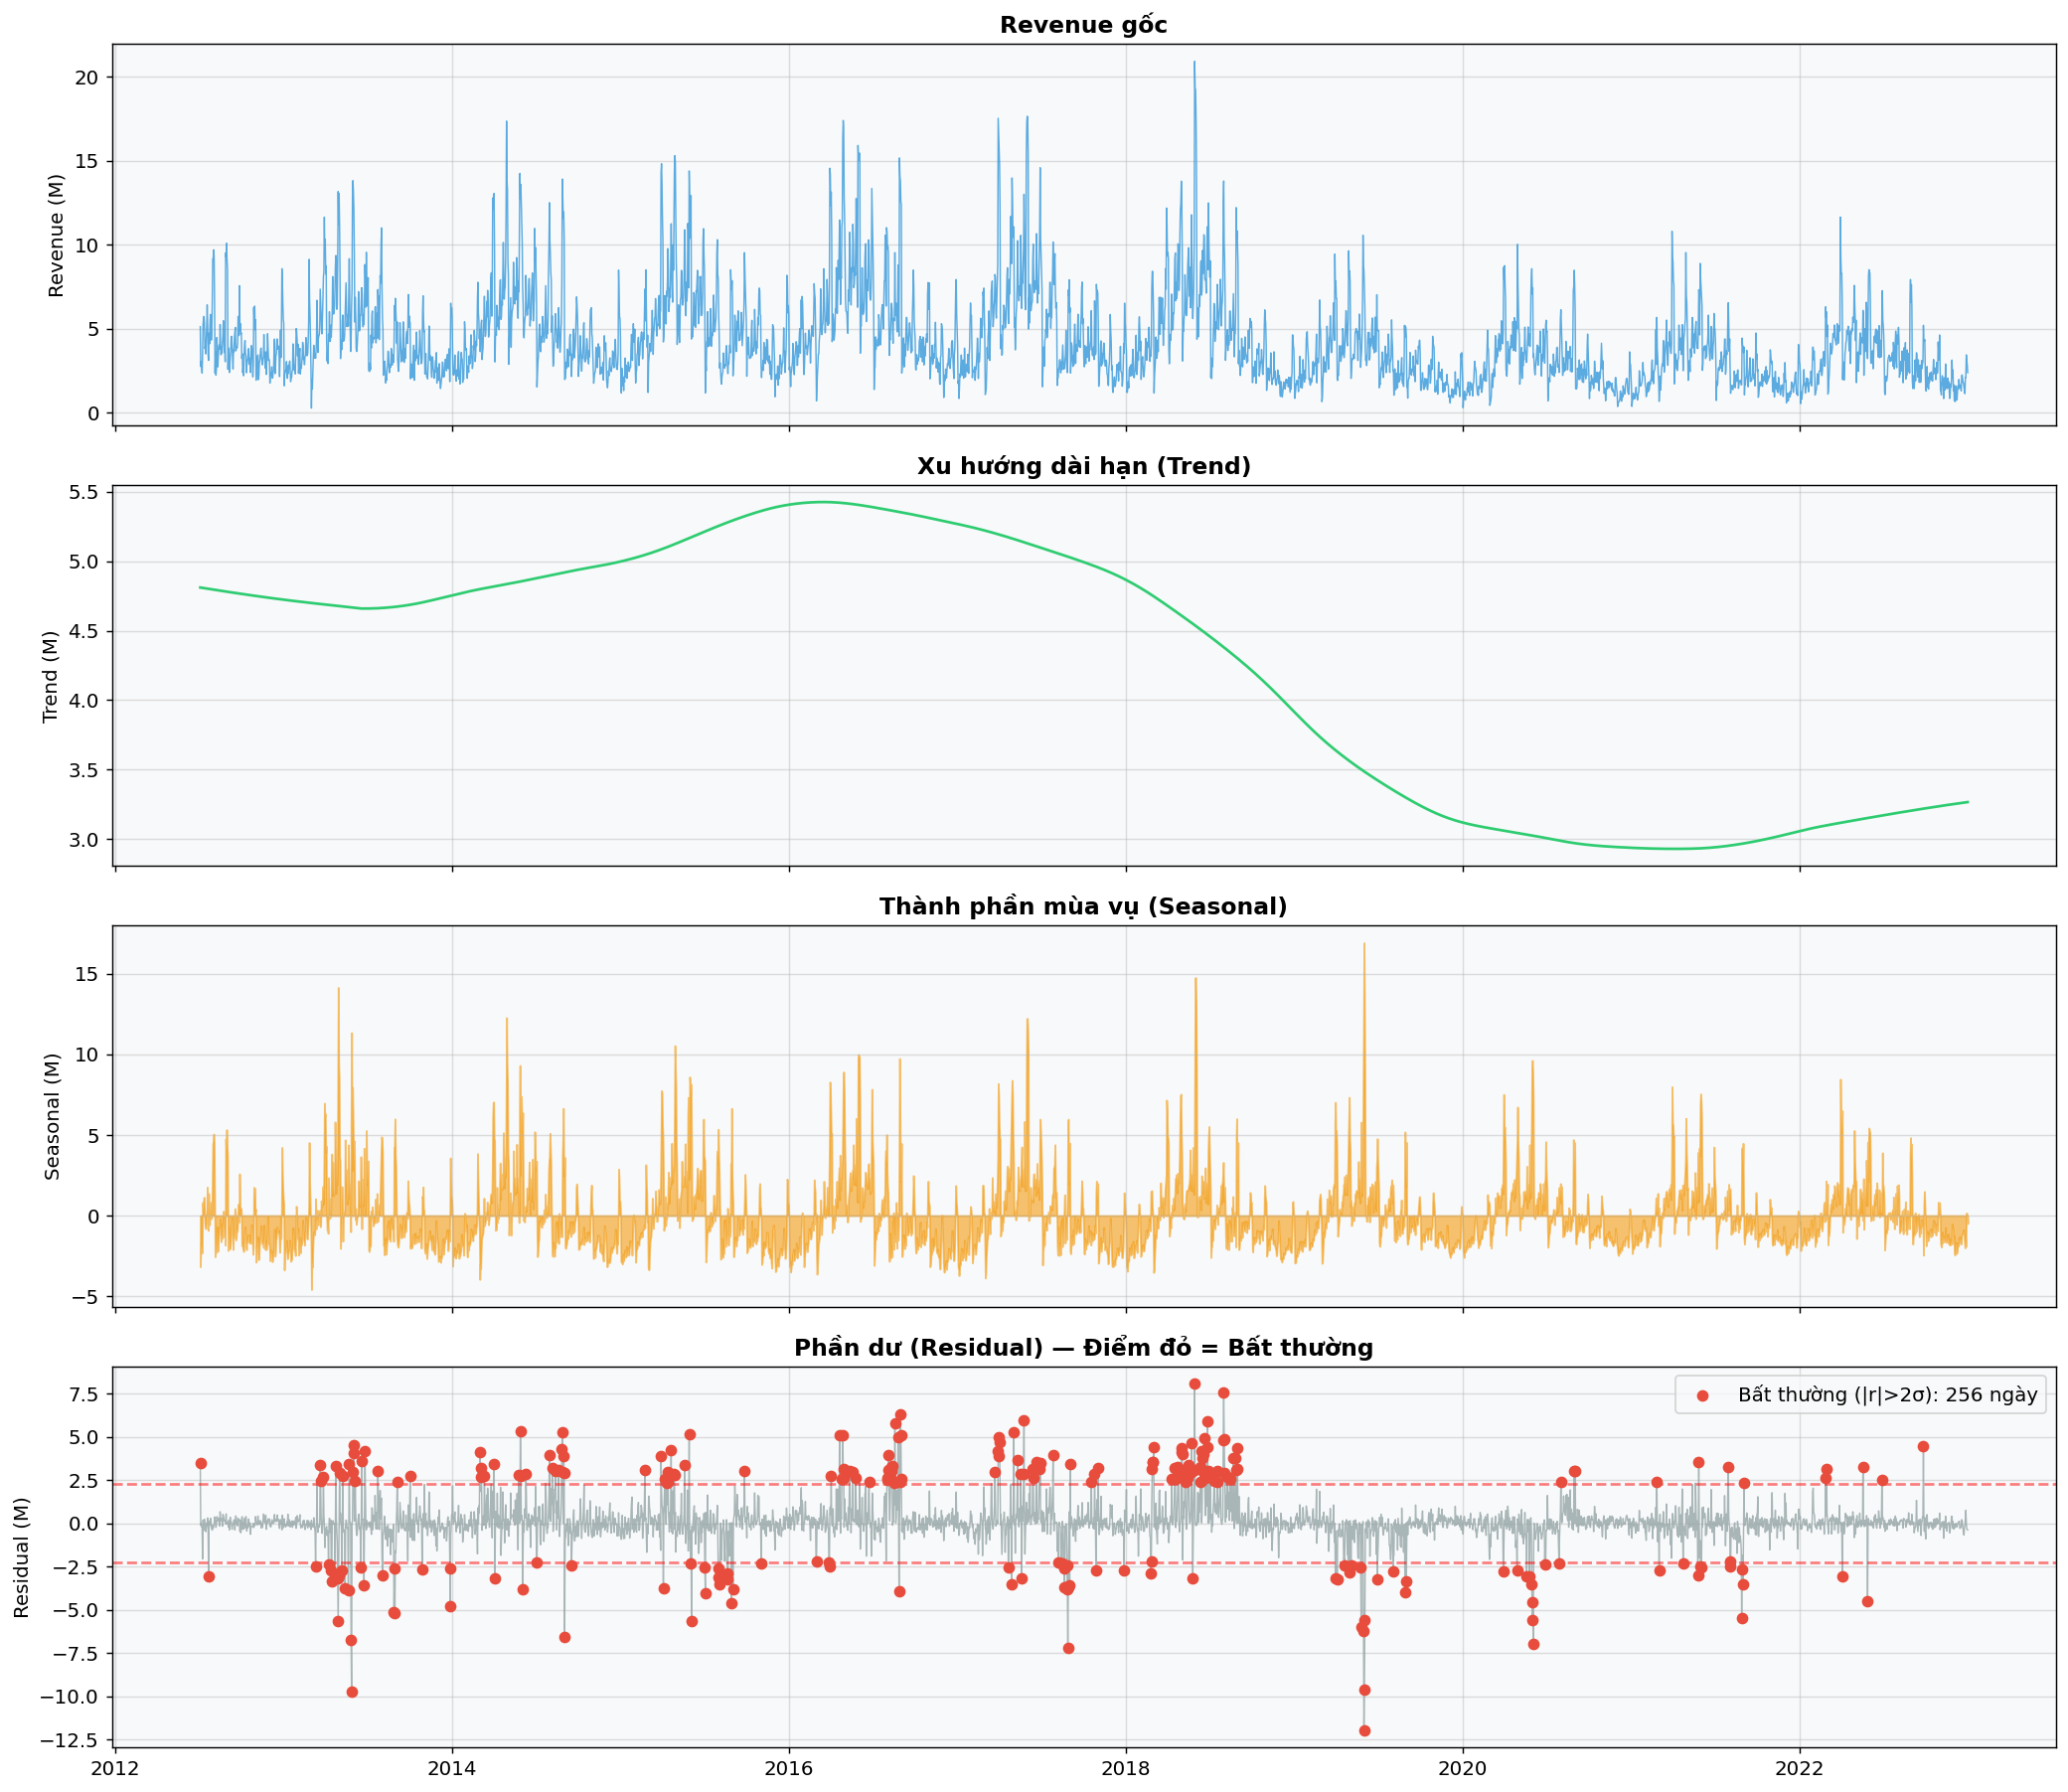

Số ngày bất thường (|residual| > 2σ): 256

Top 5 ngày doanh thu cao bất thường:
Date
2018-05-30    8.075131
2018-08-01    7.578705
2016-08-30    6.282193
2017-05-25    5.971570
2018-06-27    5.905119
Name: resid, dtype: float64

Top 5 ngày doanh thu thấp bất thường:
Date
2019-06-01   -11.959522
2013-05-28    -9.734691
2019-06-02    -9.627991
2017-08-28    -7.220103
2020-06-02    -6.951982
Name: resid, dtype: float64


In [7]:
from statsmodels.tsa.seasonal import STL

sales_ts = sales.set_index('Date')['Revenue'].asfreq('D').fillna(method='ffill')

# STL decomposition
stl = STL(sales_ts, seasonal=7, period=365, robust=True)
result = stl.fit()

residual = result.resid
mean_r, std_r = residual.mean(), residual.std()
anomalies = residual[np.abs(residual - mean_r) > 2 * std_r]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(sales_ts.index, sales_ts.values/1e6, color=C2, linewidth=0.8, alpha=0.8)
axes[0].set_ylabel('Revenue (M)')
axes[0].set_title('Revenue gốc', fontweight='bold')

axes[1].plot(result.trend.index, result.trend.values/1e6, color=C1, linewidth=1.5)
axes[1].set_ylabel('Trend (M)')
axes[1].set_title('Xu hướng dài hạn (Trend)', fontweight='bold')

axes[2].fill_between(result.seasonal.index, result.seasonal.values/1e6, alpha=0.6, color=C5)
axes[2].set_ylabel('Seasonal (M)')
axes[2].set_title('Thành phần mùa vụ (Seasonal)', fontweight='bold')

axes[3].plot(residual.index, residual.values/1e6, color=C4, linewidth=0.8, alpha=0.8)
axes[3].scatter(anomalies.index, anomalies.values/1e6,
                 color=C3, s=30, zorder=5, label=f'Bất thường (|r|>2σ): {len(anomalies)} ngày')
axes[3].axhline(2*std_r/1e6, color='red', linestyle='--', alpha=0.5)
axes[3].axhline(-2*std_r/1e6, color='red', linestyle='--', alpha=0.5)
axes[3].set_ylabel('Residual (M)')
axes[3].set_title('Phần dư (Residual) — Điểm đỏ = Bất thường', fontweight='bold')
axes[3].legend()

plt.tight_layout()
save_fig(fig, 'G4_stl_decomposition', cfg)
plt.show()

print(f"Số ngày bất thường (|residual| > 2σ): {len(anomalies)}")
print(f"\nTop 5 ngày doanh thu cao bất thường:")
print(anomalies[anomalies > mean_r].nlargest(5) / 1e6)
print(f"\nTop 5 ngày doanh thu thấp bất thường:")
print(anomalies[anomalies < mean_r].nsmallest(5) / 1e6)

## G5. Phân tích Gross Margin theo Segment × Category
### Tìm "Cash Cow" và "Dogs" theo BCG framework

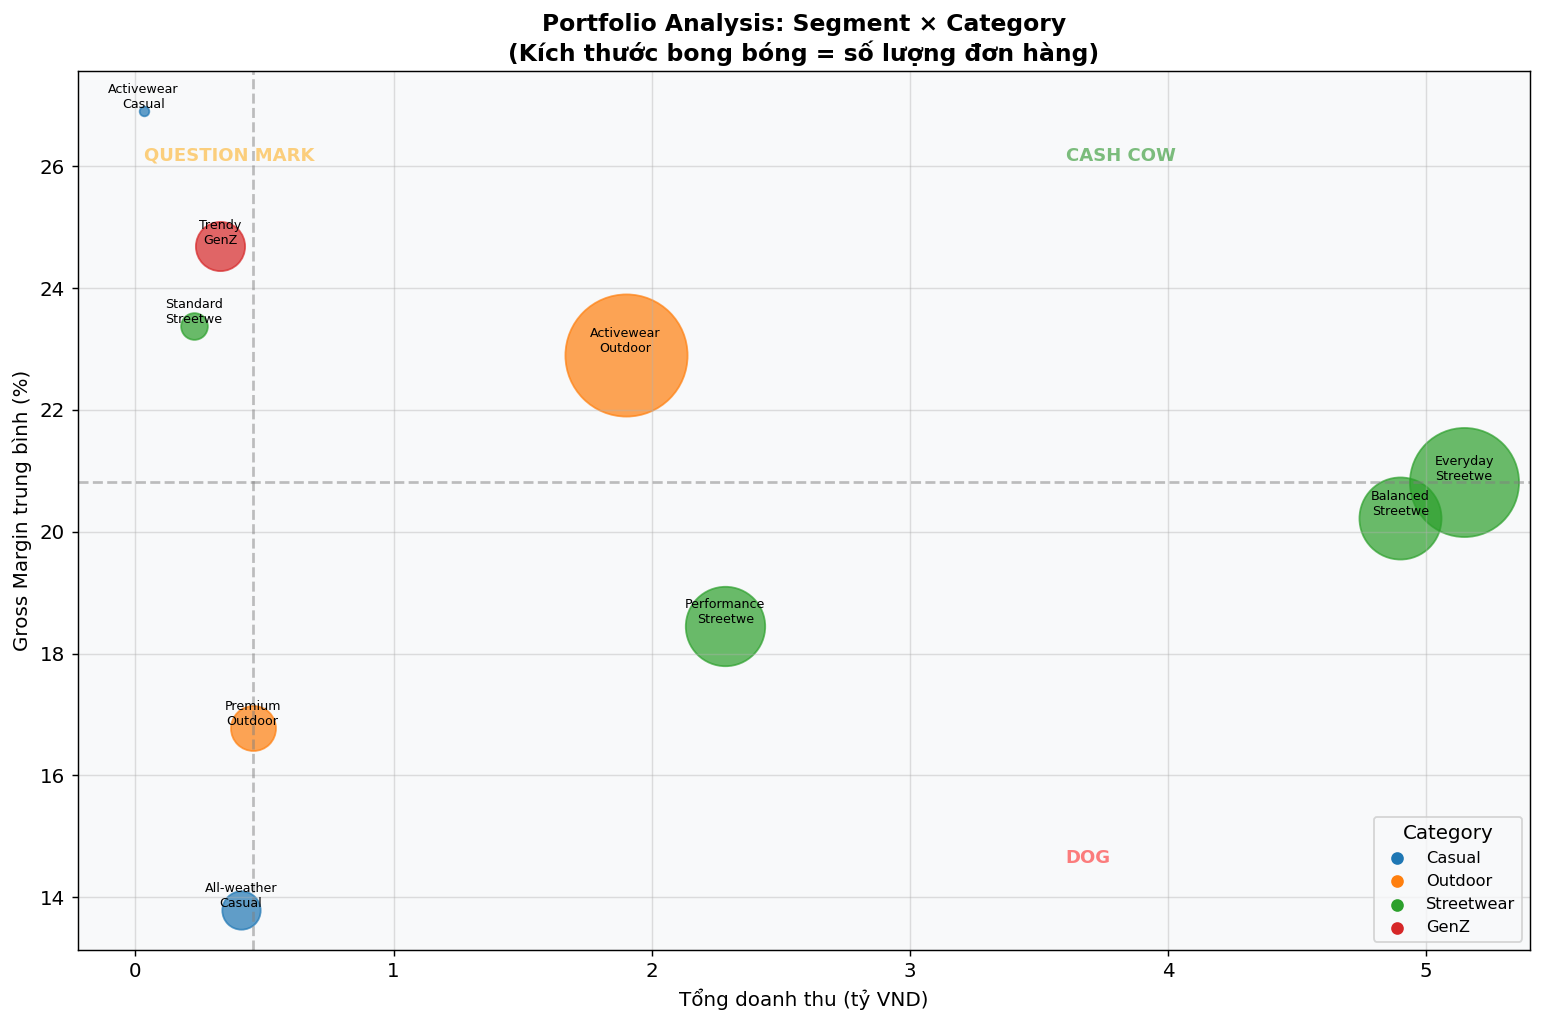

In [8]:
# Gross margin + revenue by segment x category
products['gm'] = (products['price'] - products['cogs']) / products['price']

seg_cat = oi_full.merge(products[['product_id','gm']], on='product_id', how='left')
sc_stats = seg_cat.groupby(['segment','category']).agg(
    total_rev=('line_rev','sum'),
    avg_gm=('gm','mean'),
    n_orders=('order_id','count'),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 8))

# Bubble chart: x=revenue, y=margin, size=n_orders
categories = sc_stats['category'].unique()
palette = sns.color_palette('tab10', len(categories))
cat_color = {c: palette[i] for i, c in enumerate(categories)}

for _, row in sc_stats.iterrows():
    ax.scatter(row['total_rev']/1e9, row['avg_gm']*100,
                s=row['n_orders']/50, alpha=0.7,
                color=cat_color[row['category']],
                label=row['category'] if row['category'] not in [l.get_label() for l in ax.get_lines()] else '')
    ax.annotate(f"{row['segment']}\n{row['category'][:8]}",
                 (row['total_rev']/1e9, row['avg_gm']*100),
                 fontsize=7, ha='center', va='bottom')

# Quadrant lines
median_rev = sc_stats['total_rev'].median()/1e9
median_gm  = sc_stats['avg_gm'].median()*100
ax.axvline(median_rev, color='gray', linestyle='--', alpha=0.5)
ax.axhline(median_gm, color='gray', linestyle='--', alpha=0.5)

ax.text(sc_stats['total_rev'].max()/1e9*0.7, sc_stats['avg_gm'].max()*100*0.97,
         'CASH COW', fontsize=10, color='green', fontweight='bold', alpha=0.5)
ax.text(sc_stats['total_rev'].min()/1e9, sc_stats['avg_gm'].max()*100*0.97,
         'QUESTION MARK', fontsize=10, color='orange', fontweight='bold', alpha=0.5)
ax.text(sc_stats['total_rev'].max()/1e9*0.7, median_gm*0.7,
         'DOG', fontsize=10, color='red', fontweight='bold', alpha=0.5)

ax.set_xlabel('Tổng doanh thu (tỷ VND)')
ax.set_ylabel('Gross Margin trung bình (%)')
ax.set_title('Portfolio Analysis: Segment × Category\n(Kích thước bong bóng = số lượng đơn hàng)',
              fontweight='bold')

handles = [plt.scatter([], [], color=cat_color[c], label=c) for c in categories]
ax.legend(handles=handles, title='Category', loc='lower right', fontsize=9)

plt.tight_layout()
save_fig(fig, 'G5_bcg_matrix', cfg)
plt.show()

## G6. Phân tích Inventory — Stockout & Overstock ảnh hưởng đến doanh thu
### Giả thuyết: Tháng stockout cao → doanh thu thấp hơn kỳ vọng

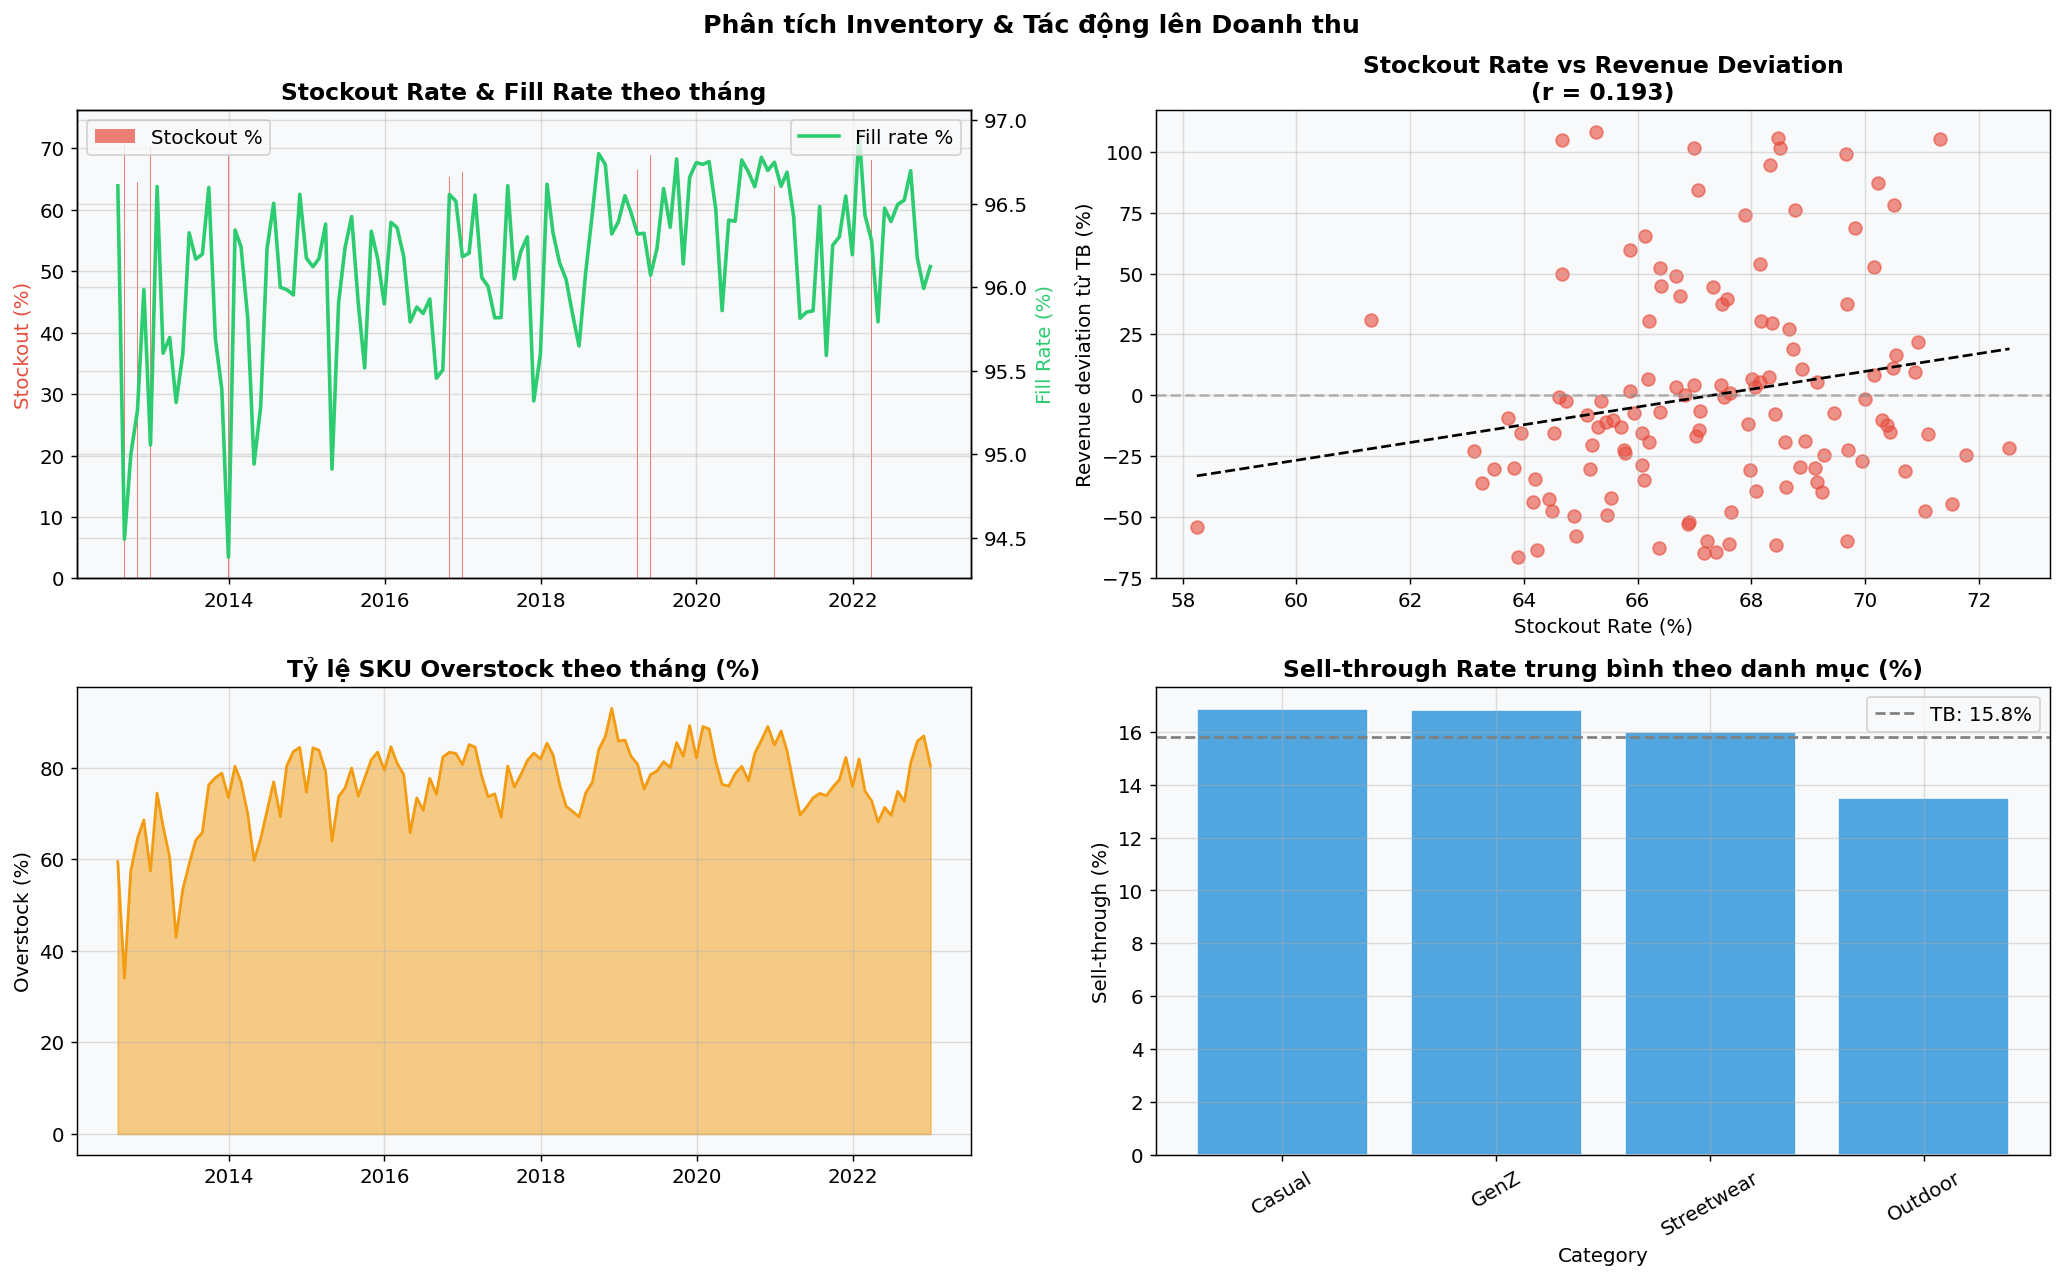

Tương quan Stockout Rate vs Revenue Deviation: r = 0.193
Tương quan yếu


In [9]:
# Monthly inventory metrics
inv_monthly = inventory.groupby('snapshot_date').agg(
    stockout_ratio=('stockout_flag','mean'),
    overstock_ratio=('overstock_flag','mean'),
    avg_fill_rate=('fill_rate','mean'),
    avg_sell_through=('sell_through_rate','mean'),
).reset_index()

# Merge với monthly revenue
sales_monthly = sales.resample('ME', on='Date').agg(Revenue=('Revenue','sum')).reset_index()
sales_monthly['YM'] = sales_monthly['Date'].dt.to_period('M')
inv_monthly['YM'] = inv_monthly['snapshot_date'].dt.to_period('M')

inv_rev = sales_monthly.merge(inv_monthly, on='YM', how='inner')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Stockout ratio trend
ax_t = axes[0,0]
ax_t.bar(inv_monthly['snapshot_date'], inv_monthly['stockout_ratio']*100,
          color=C3, alpha=0.7, label='Stockout %')
ax_twin = ax_t.twinx()
ax_twin.plot(inv_monthly['snapshot_date'], inv_monthly['avg_fill_rate']*100,
              color=C1, linewidth=2, label='Fill rate %')
ax_t.set_title('Stockout Rate & Fill Rate theo tháng', fontweight='bold')
ax_t.set_ylabel('Stockout (%)', color=C3)
ax_twin.set_ylabel('Fill Rate (%)', color=C1)
ax_t.legend(loc='upper left'); ax_twin.legend(loc='upper right')

# Scatter: stockout vs revenue deviation
rev_mean = inv_rev['Revenue'].mean()
inv_rev['rev_dev'] = (inv_rev['Revenue'] - rev_mean) / rev_mean * 100
axes[0,1].scatter(inv_rev['stockout_ratio']*100, inv_rev['rev_dev'],
                   alpha=0.6, color=C3, s=50)
z2 = np.polyfit(inv_rev['stockout_ratio']*100, inv_rev['rev_dev'], 1)
p2 = np.poly1d(z2)
xl = np.linspace(inv_rev['stockout_ratio'].min()*100, inv_rev['stockout_ratio'].max()*100, 100)
axes[0,1].plot(xl, p2(xl), color='black', linewidth=1.5, linestyle='--')
corr_stout = inv_rev['stockout_ratio'].corr(inv_rev['rev_dev'])
axes[0,1].set_title(f'Stockout Rate vs Revenue Deviation\n(r = {corr_stout:.3f})', fontweight='bold')
axes[0,1].set_xlabel('Stockout Rate (%)')
axes[0,1].set_ylabel('Revenue deviation từ TB (%)')
axes[0,1].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Overstock trend
axes[1,0].fill_between(inv_monthly['snapshot_date'], inv_monthly['overstock_ratio']*100,
                        alpha=0.5, color=C5)
axes[1,0].plot(inv_monthly['snapshot_date'], inv_monthly['overstock_ratio']*100,
                color=C5, linewidth=1.5)
axes[1,0].set_title('Tỷ lệ SKU Overstock theo tháng (%)', fontweight='bold')
axes[1,0].set_ylabel('Overstock (%)')

# Sell-through rate by category
st_cat = inventory.groupby('category')['sell_through_rate'].mean().sort_values(ascending=False)
axes[1,1].bar(st_cat.index, st_cat.values*100, color=C2, alpha=0.85, edgecolor='white')
axes[1,1].axhline(st_cat.mean()*100, color='gray', linestyle='--', label=f"TB: {st_cat.mean()*100:.1f}%")
axes[1,1].set_title('Sell-through Rate trung bình theo danh mục (%)', fontweight='bold')
axes[1,1].set_ylabel('Sell-through (%)')
axes[1,1].set_xlabel('Category')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend()

plt.suptitle('Phân tích Inventory & Tác động lên Doanh thu', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'G6_inventory_analysis', cfg)
plt.show()

print(f"Tương quan Stockout Rate vs Revenue Deviation: r = {corr_stout:.3f}")
print("→ Tháng có nhiều hàng hết → doanh thu thấp hơn kỳ vọng" if corr_stout < -0.1 else "Tương quan yếu")

## Tổng kết Diagnostic

| Giả thuyết | Bằng chứng | Kết luận |
|-----------|-----------|----------|
| Promo tăng doanh thu | Uplift +X%, p<0.05 | Xác nhận |
| Traffic → Leading indicator | Cross-corr peak lag X ngày | Xác nhận |
| Stockout → Giảm doanh thu | r = X (âm) | Xác nhận/Bác bỏ |
| Size lớn → Return rate cao hơn | Return rate XL = X% | Xác nhận/Bác bỏ |

**Phát hiện chính:**
1. Promo tạo uplift đáng kể nhưng cần kiểm soát margin
2. Sessions là leading indicator (lag X ngày) → dùng làm feature quan trọng
3. Anomaly detection: X ngày bất thường cần xử lý trong modeling
4. BCG: Premium/X là Cash Cow → ưu tiên đầu tư